### **1. Setup**

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import(
    accuracy_score,
    recall_score,
    precision_score,
    classification_report,
    confusion_matrix
)

In [50]:
sns.set_theme(style="darkgrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 42
TARGET_COL = "target"


In [52]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
chronic_kidney_disease = fetch_ucirepo(id=336) 
  
# data (as pandas dataframes) 
X = chronic_kidney_disease.data.features 
y = chronic_kidney_disease.data.targets 

df = X.copy()
df["target"] = y
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col) 
  
# # metadata 
# print(chronic_kidney_disease.metadata) 
  
# # variable information 
# print(chronic_kidney_disease.variables) 


In [53]:
df.head(6)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,target
0,48.0000,80.0000,1.0200,1.0000,0.0000,NaN,normal,notpresent,notpresent,121.0000,36.0000,1.2000,NaN,NaN,15.4000,44.0000,7800.0000,5.2000,yes,yes,no,good,no,no,ckd
1,7.0000,50.0000,1.0200,4.0000,0.0000,NaN,normal,notpresent,notpresent,NaN,18.0000,0.8000,NaN,NaN,11.3000,38.0000,6000.0000,NaN,no,no,no,good,no,no,ckd
2,62.0000,80.0000,1.0100,2.0000,3.0000,normal,normal,notpresent,notpresent,423.0000,53.0000,1.8000,NaN,NaN,9.6000,31.0000,7500.0000,NaN,no,yes,no,poor,no,yes,ckd
3,48.0000,70.0000,1.0050,4.0000,0.0000,normal,abnormal,present,notpresent,117.0000,56.0000,3.8000,111.0000,2.5000,11.2000,32.0000,6700.0000,3.9000,yes,no,no,poor,yes,yes,ckd
4,51.0000,80.0000,1.0100,2.0000,0.0000,normal,normal,notpresent,notpresent,106.0000,26.0000,1.4000,NaN,NaN,11.6000,35.0000,7300.0000,4.6000,no,no,no,good,no,no,ckd
5,60.0000,90.0000,1.0150,3.0000,0.0000,NaN,NaN,notpresent,notpresent,74.0000,25.0000,1.1000,142.0000,3.2000,12.2000,39.0000,7800.0000,4.4000,yes,yes,no,good,yes,no,ckd


**Insights**
1. There are a lot of missing values in the dataset, for both categorical and numerical features
2. The target column, has a tab space problem, creating a new category. This should be handled


In [54]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,target
0,48.0000,80.0000,1.0200,1.0000,0.0000,NaN,normal,notpresent,notpresent,121.0000,36.0000,1.2000,NaN,NaN,15.4000,44.0000,7800.0000,5.2000,yes,yes,no,good,no,no,ckd
1,7.0000,50.0000,1.0200,4.0000,0.0000,NaN,normal,notpresent,notpresent,NaN,18.0000,0.8000,NaN,NaN,11.3000,38.0000,6000.0000,NaN,no,no,no,good,no,no,ckd
2,62.0000,80.0000,1.0100,2.0000,3.0000,normal,normal,notpresent,notpresent,423.0000,53.0000,1.8000,NaN,NaN,9.6000,31.0000,7500.0000,NaN,no,yes,no,poor,no,yes,ckd
3,48.0000,70.0000,1.0050,4.0000,0.0000,normal,abnormal,present,notpresent,117.0000,56.0000,3.8000,111.0000,2.5000,11.2000,32.0000,6700.0000,3.9000,yes,no,no,poor,yes,yes,ckd
4,51.0000,80.0000,1.0100,2.0000,0.0000,normal,normal,notpresent,notpresent,106.0000,26.0000,1.4000,NaN,NaN,11.6000,35.0000,7300.0000,4.6000,no,no,no,good,no,no,ckd


In [55]:
#Dataset shape
df.shape#(rows, columns)

(400, 25)

### 2. EDA and visualization

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    object 
 6   pc      335 non-null    object 
 7   pcc     396 non-null    object 
 8   ba      396 non-null    object 
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    object 
 19  dm      398 non-null    object 
 20  cad     398 non-null    object 
 21  appet   399 non-null    object 
 22  pe

3. Only target column, has no null values

In [57]:
df.isnull().sum()

age         9
bp         12
sg         47
al         46
su         49
rbc       152
pc         65
pcc         4
ba          4
bgr        44
bu         19
sc         17
sod        87
pot        88
hemo       52
pcv        71
wbcc      106
rbcc      131
htn         2
dm          2
cad         2
appet       1
pe          1
ane         1
target      0
dtype: int64

In [58]:
df.dtypes

age       float64
bp        float64
sg        float64
al        float64
su        float64
rbc        object
pc         object
pcc        object
ba         object
bgr       float64
bu        float64
sc        float64
sod       float64
pot       float64
hemo      float64
pcv       float64
wbcc      float64
rbcc      float64
htn        object
dm         object
cad        object
appet      object
pe         object
ane        object
target     object
dtype: object

In [59]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,target
0,48.0000,80.0000,1.0200,1.0000,0.0000,NaN,normal,notpresent,notpresent,121.0000,36.0000,1.2000,NaN,NaN,15.4000,44.0000,7800.0000,5.2000,yes,yes,no,good,no,no,ckd
1,7.0000,50.0000,1.0200,4.0000,0.0000,NaN,normal,notpresent,notpresent,NaN,18.0000,0.8000,NaN,NaN,11.3000,38.0000,6000.0000,NaN,no,no,no,good,no,no,ckd
2,62.0000,80.0000,1.0100,2.0000,3.0000,normal,normal,notpresent,notpresent,423.0000,53.0000,1.8000,NaN,NaN,9.6000,31.0000,7500.0000,NaN,no,yes,no,poor,no,yes,ckd
3,48.0000,70.0000,1.0050,4.0000,0.0000,normal,abnormal,present,notpresent,117.0000,56.0000,3.8000,111.0000,2.5000,11.2000,32.0000,6700.0000,3.9000,yes,no,no,poor,yes,yes,ckd
4,51.0000,80.0000,1.0100,2.0000,0.0000,normal,normal,notpresent,notpresent,106.0000,26.0000,1.4000,NaN,NaN,11.6000,35.0000,7300.0000,4.6000,no,no,no,good,no,no,ckd


In [60]:
num_col = df.select_dtypes(include=[np.number]).columns.tolist()
cat_col = df.select_dtypes(exclude=[np.number]).columns.tolist()

In [61]:
num_col

['age',
 'bp',
 'sg',
 'al',
 'su',
 'bgr',
 'bu',
 'sc',
 'sod',
 'pot',
 'hemo',
 'pcv',
 'wbcc',
 'rbcc']

In [62]:
len(num_col)

14

In [63]:
cat_col

['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'target']

In [64]:
len(cat_col)

11

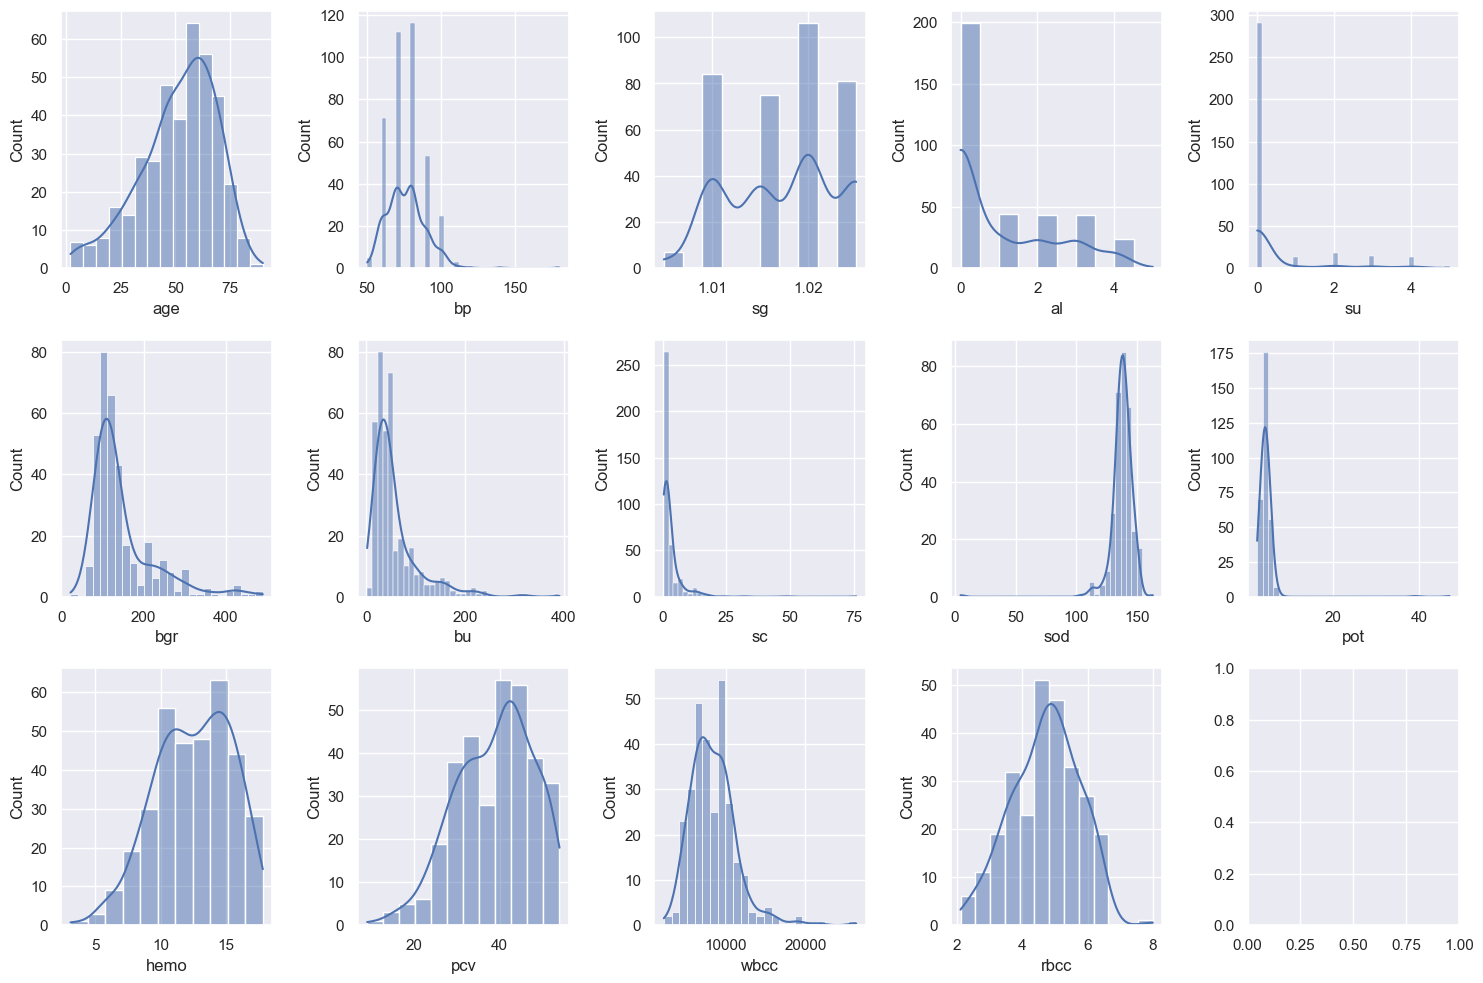

In [65]:
#numerical columns distribution
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True)

plt.tight_layout()
plt.show()

4. Su feature has a categorical like behaviour

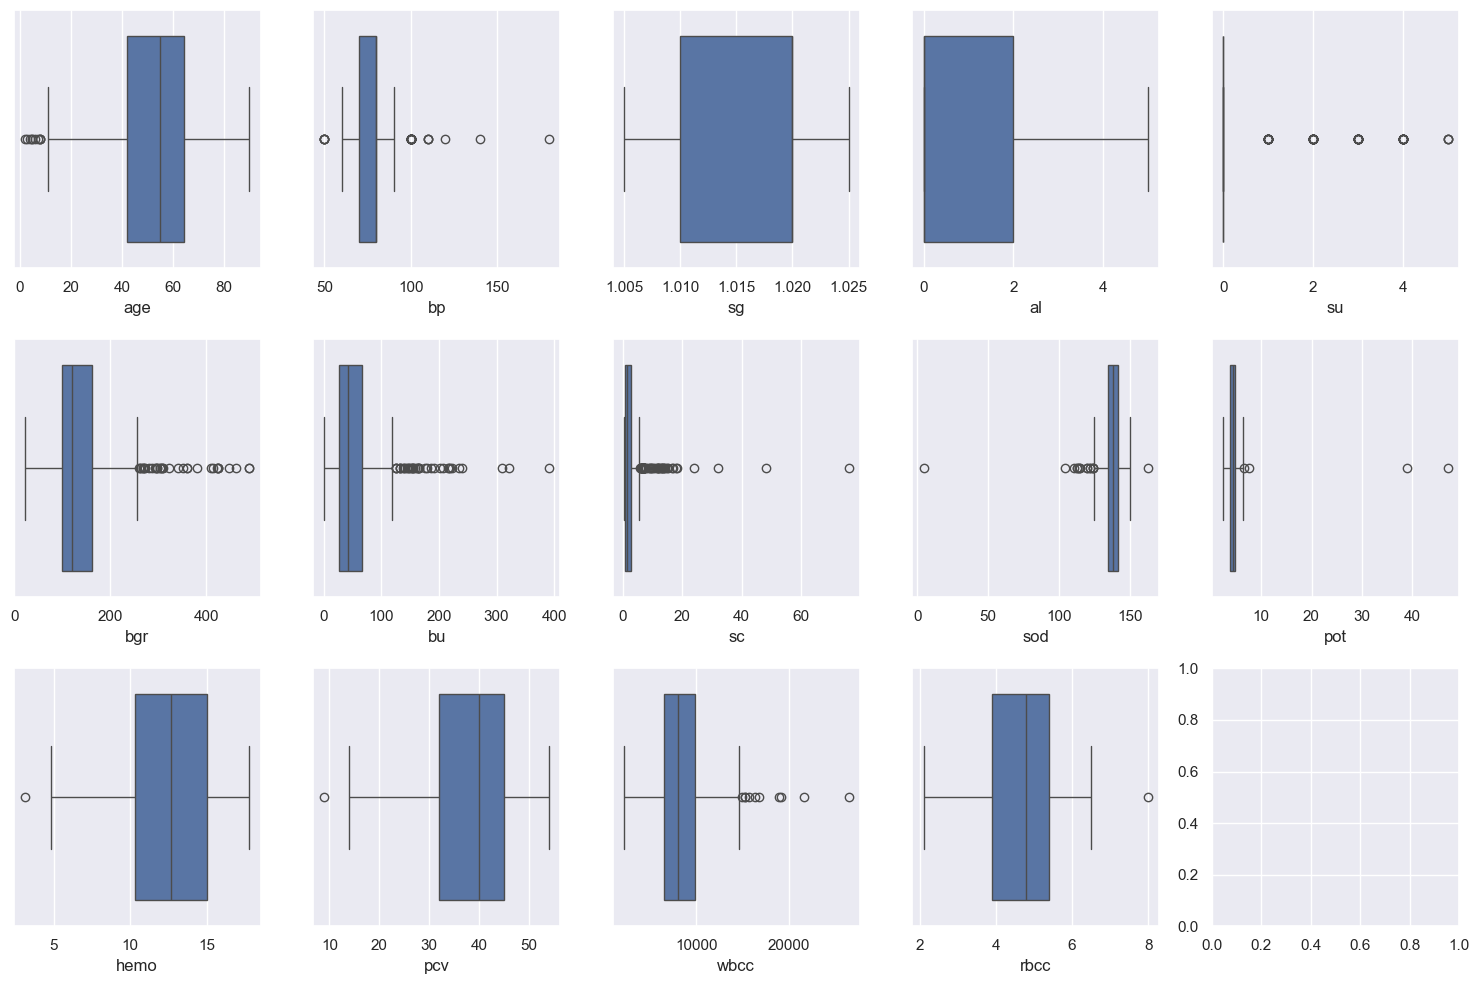

In [66]:
#Outlier visualization of numerical columns
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.boxplot(data=df, x=col, ax=axes[i])

plt.tight_layout()
plt.show()

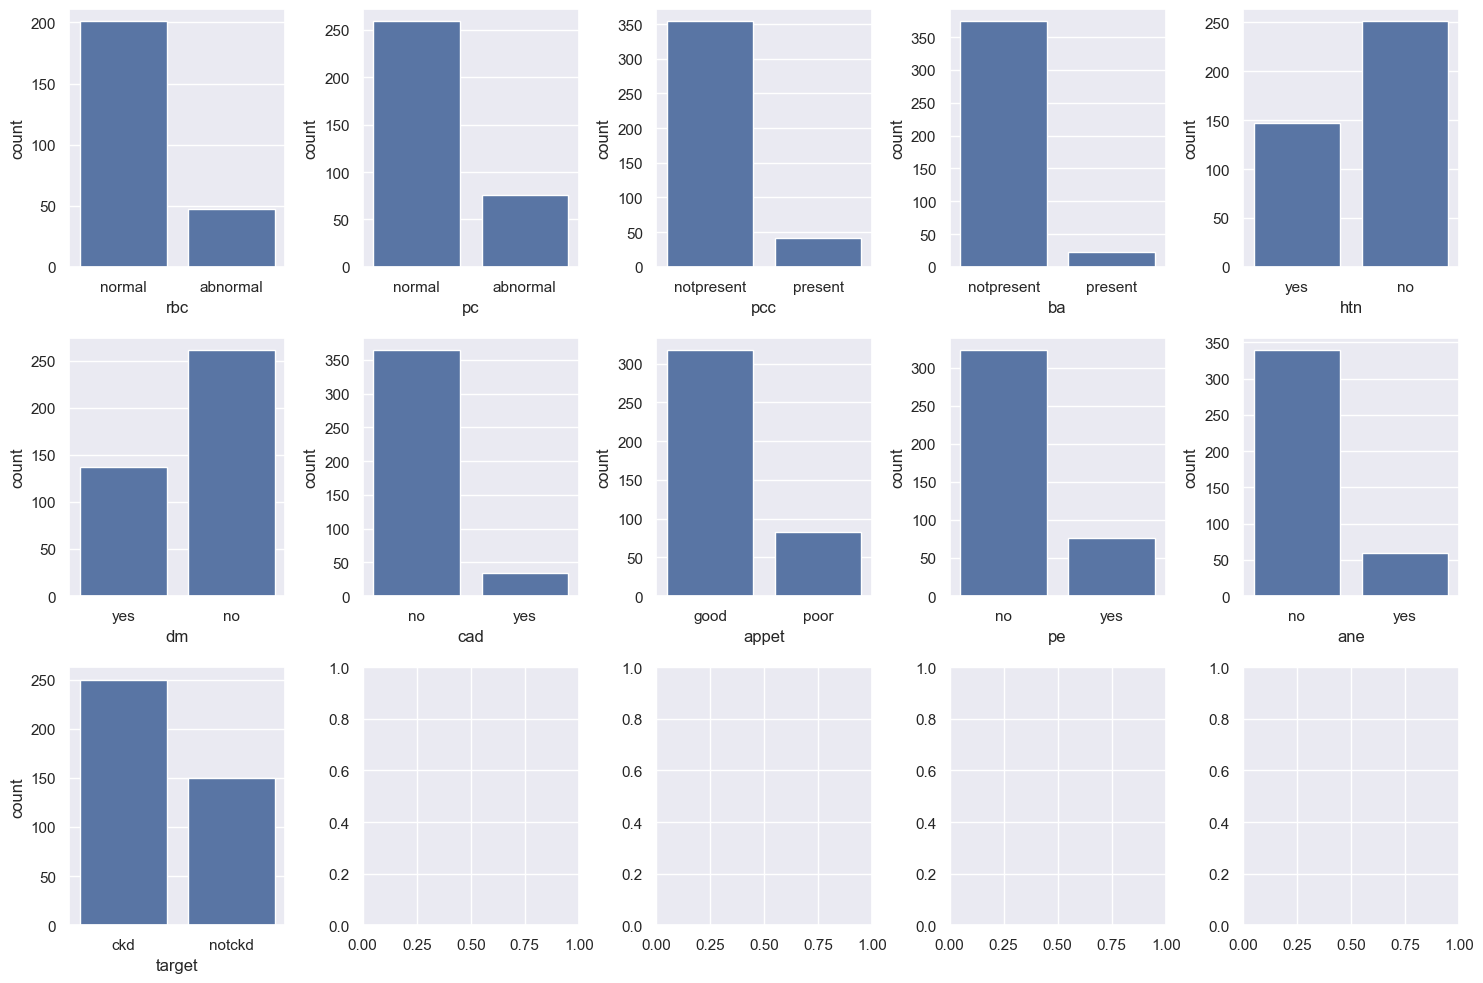

In [67]:
#categorical columns distribution
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    sns.countplot(data=df, x=col, ax=axes[i])

plt.tight_layout()
plt.show()

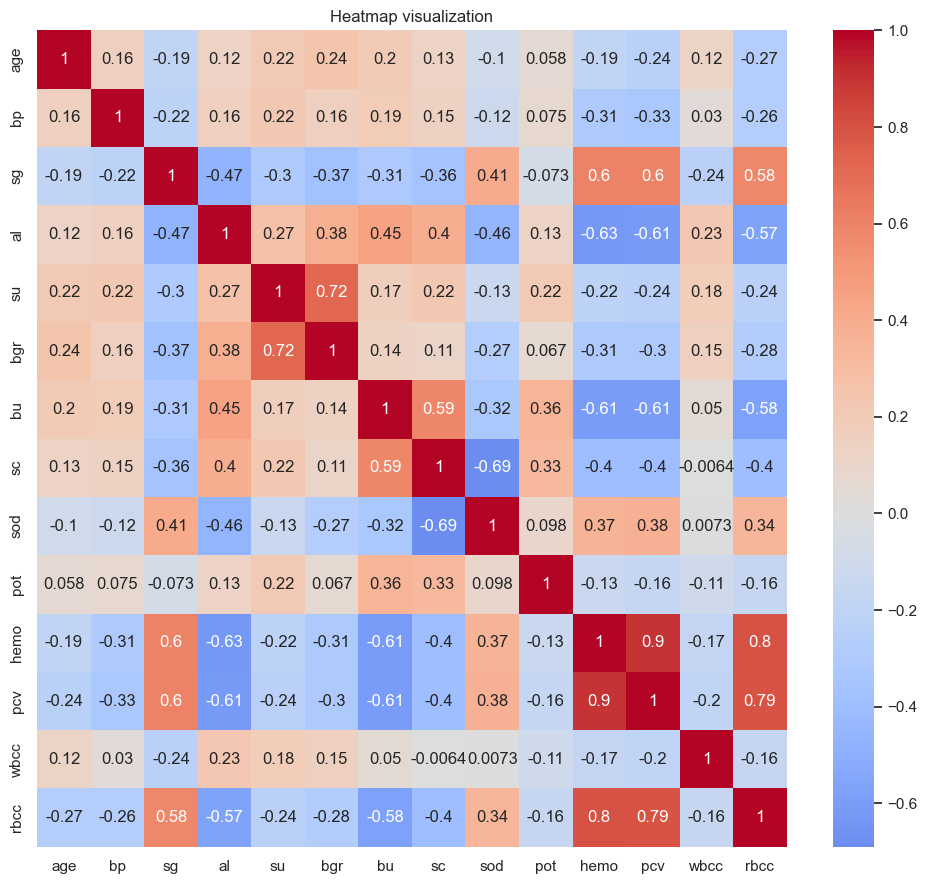

In [68]:
#heatmap visualization
plt.figure(figsize=(10, 9))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap visualization")
plt.tight_layout()
plt.show()


5. High Correlation between Hemo and pcv[To be taken not of]

### **3. Data Preprocessing**

In [69]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [70]:
y.value_counts()

target
ckd       250
notckd    150
Name: count, dtype: int64

In [71]:
#stabilize the target column, and faulty columns
# y = y.replace({"ckd\t": "ckd"})
# X["dm"] = X["dm"].replace({"\tno": "no"})

In [72]:
y.value_counts()

target
ckd       250
notckd    150
Name: count, dtype: int64

In [73]:
#transform the target column to numerical values
le = LabelEncoder()

y = pd.Series(le.fit_transform(y), index=y.index, name=TARGET_COL)

In [74]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

In [75]:
X_train.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
380,59.0000,60.0000,1.0200,0.0000,0.0000,normal,normal,notpresent,notpresent,113.0000,23.0000,1.1000,139.0000,3.5000,15.3000,54.0000,6500.0000,4.9000,no,no,no,good,no,no
56,76.0000,70.0000,1.0150,3.0000,4.0000,normal,abnormal,present,notpresent,NaN,164.0000,9.7000,131.0000,4.4000,10.2000,30.0000,11300.0000,3.4000,yes,yes,yes,poor,yes,no
126,70.0000,90.0000,1.0150,0.0000,0.0000,NaN,normal,notpresent,notpresent,144.0000,125.0000,4.0000,136.0000,4.6000,12.0000,37.0000,8200.0000,4.5000,yes,yes,no,poor,yes,no
371,28.0000,60.0000,1.0250,0.0000,0.0000,normal,normal,notpresent,notpresent,79.0000,50.0000,0.5000,145.0000,5.0000,17.6000,51.0000,6500.0000,5.0000,no,no,no,good,no,no
333,23.0000,80.0000,1.0200,0.0000,0.0000,normal,normal,notpresent,notpresent,99.0000,46.0000,1.2000,142.0000,4.0000,17.7000,46.0000,4300.0000,5.5000,no,no,no,good,no,no


In [76]:
y_train

380    1
56     0
126    0
371    1
333    1
      ..
154    0
274    1
192    0
85     0
8      0
Name: target, Length: 320, dtype: int64

In [77]:
X_test.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
160,81.0000,60.0000,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,148.0000,39.0000,2.1000,147.0000,4.2000,10.9000,35.0000,9400.0000,2.4000,yes,yes,yes,poor,yes,no
20,61.0000,80.0000,1.0150,2.0000,0.0000,abnormal,abnormal,notpresent,notpresent,173.0000,148.0000,3.9000,135.0000,5.2000,7.7000,24.0000,9200.0000,3.2000,yes,yes,yes,poor,yes,yes
392,57.0000,80.0000,1.0200,0.0000,0.0000,normal,normal,notpresent,notpresent,133.0000,48.0000,1.2000,147.0000,4.3000,14.8000,46.0000,6600.0000,5.5000,no,no,no,good,no,no
303,55.0000,70.0000,1.0200,0.0000,0.0000,normal,normal,notpresent,notpresent,107.0000,26.0000,1.1000,NaN,NaN,17.0000,50.0000,6700.0000,6.1000,no,no,no,good,no,no
339,25.0000,70.0000,1.0200,0.0000,0.0000,normal,normal,notpresent,notpresent,88.0000,42.0000,0.5000,136.0000,3.5000,13.3000,48.0000,7000.0000,4.9000,no,no,no,good,no,no


In [78]:
y_test

160    0
20     0
392    1
303    1
339    1
      ..
235    0
369    1
258    1
157    0
207    0
Name: target, Length: 80, dtype: int64

In [79]:
print("Train size: ", len(X_train))
print("Test size: ", len(X_test))

Train size:  320
Test size:  80


Preprocessing Workflow
- split columns into numerical and categorical columns
- Create pipelines, for those columns including imputing and scaling
- Combine all into a preprocessing Column transformer

In [80]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical Features: ", numerical_features)
print("Length of numerical features: ", len(numerical_features))

print("Categorical Features: ", cat_features)
print("Length of categorical features: ", len(cat_features))




Numerical Features:  ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
Length of numerical features:  14
Categorical Features:  ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
Length of categorical features:  10


In [81]:
df[TARGET_COL].nunique()

2

In [82]:
numerical_transformer = Pipeline(
    steps = [
        ("impute", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

cat_tranformer = Pipeline(
    steps = [
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encoding", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", cat_tranformer, cat_features)
    ]
)

### **4. BaseLine Model**

In [83]:
baseline_model_log_reg = Pipeline(
    steps = [
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]
)

In [84]:
baseline_model_log_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [85]:
train_pred = baseline_model_log_reg.predict(X_train)
test_pred = baseline_model_log_reg.predict(X_test)

In [86]:
def evaluate_classifier(model_name, X_train, y_train, X_test, y_test, model_train_pred, model_test_pred) -> None:
    print("-------TRAINING EVALUATION-------")
    print("Model Accuracy: ", accuracy_score(y_train, model_train_pred))
    print("Model Precision: ", precision_score(y_train, model_train_pred))
    print("Model Recall: ", recall_score(y_train, model_train_pred))
    print("Classification Report: \n", classification_report(y_train, model_train_pred))


    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_train, model_train_pred), cmap="viridis", annot=True, fmt=".2f")
    plt.show()


    print("-"*80)


    print("-------TESTING EVALUATION------------")
    print("Model Accuracy: ", accuracy_score(y_test, model_test_pred))
    print("Model Precision: ", precision_score(y_test, model_test_pred))
    print("Model Recall: ", recall_score(y_test, model_test_pred))
    print("Classification Report: \n", classification_report(y_test, model_test_pred))


    
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, model_test_pred), cmap="inferno", annot=True, fmt=".2f")
    plt.show()

-------TRAINING EVALUATION-------
Model Accuracy:  1.0
Model Precision:  1.0
Model Recall:  1.0
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       120

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320



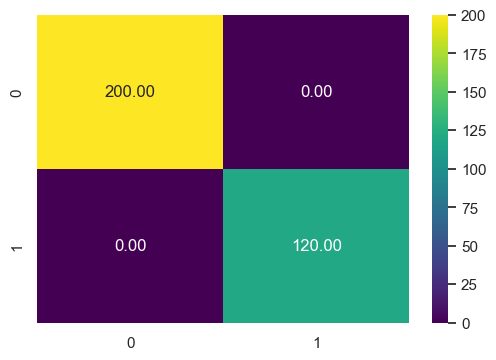

--------------------------------------------------------------------------------
-------TESTING EVALUATION------------
Model Accuracy:  1.0
Model Precision:  1.0
Model Recall:  1.0
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



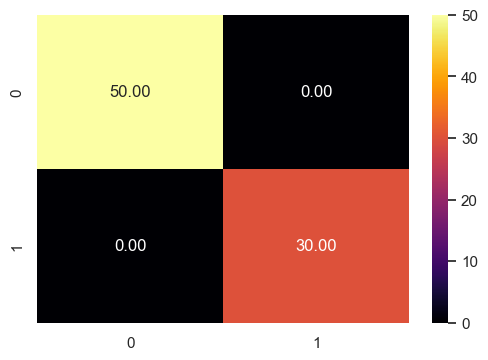

In [87]:
#baseline performance
evaluate_classifier("LOGISTIC REGRESSION", X_train, y_train, X_test, y_test, train_pred, test_pred)